# Color Image Deblurring

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Color blurring model: 
$( \mathbf{A}_{\text{color}} \otimes \mathbf{A} )\, \mathbf{x} = \mathbf{b}$

## Functions 

In [2]:
def compute_tsvd(psf, blurred_img, tol):
    eigen_A = np.fft.fft2(psf)
    tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * tsvd_filter))

def compute_tikhonov(psf, blurred_img, alpha):
    eigen_A = np.fft.fft2(psf)
    tik_filter = (np.abs(eigen_A)**2) / (np.abs(eigen_A)**2 + alpha**2)
    filtered = np.where(eigen_A != 0, tik_filter / eigen_A, 0.0)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

In [3]:
## functions stolen from Luna, thank you Luna
def plot_comparison(arr_list, label_list, row, col, figsize=(12,4), cmap=None):
    """Plot images side by side for comparison."""
    
    _, sub = plt.subplots(row, col, figsize=figsize)
    sub = sub.flatten()
    [s.axis('off') for s in sub]
    
    for sub_idx in range(len(arr_list)):
        sub[sub_idx].imshow(arr_list[sub_idx], cmap=cmap)
        sub[sub_idx].set_title(label_list[sub_idx], y=-0.1)
        
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.show()

## Importing image

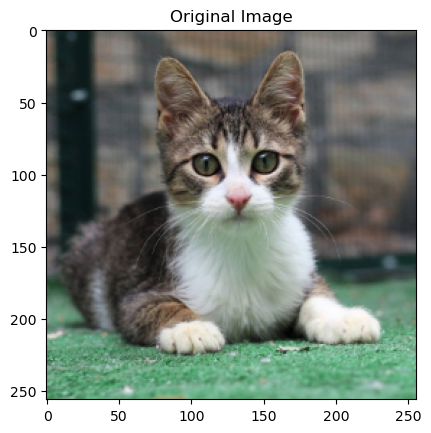

In [4]:
img = plt.imread('color_deblur_img/kitty.jpg').astype(np.float64)
if img.max() > 1:
    img = img / 255.0
H, W = img.shape[:2]

plt.imshow(img)
plt.title("Original Image")
plt.show()

## Build the PSF

In [14]:
def build_psf(H, W, sigma=3.0):
    y = np.fft.ifftshift(np.arange(-H // 2, H // 2))
    x = np.fft.ifftshift(np.arange(-W // 2, W // 2))
    X, Y = np.meshgrid(x, y)
    psf = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    psf /= psf.sum()
    return psf

In [15]:
psf = build_psf(H, W, sigma=3.0)
eigen_A = np.fft.fft2(psf) 

## Blurring The Image 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014381090728612975..1.020538645408412].


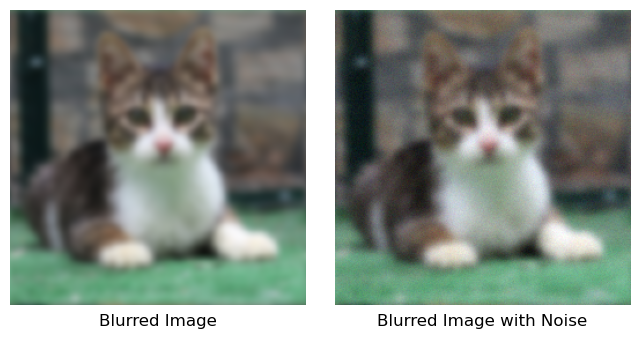

In [6]:
np.random.seed(42)

B = np.zeros_like(img)
for c in range(3):
    B[:, :, c] = np.real(np.fft.ifft2(eigen_A * np.fft.fft2(img[:, :, c])))

B_noisy = B + 0.02 * np.random.randn(H, W, 3)
plot_comparison([B, B_noisy],
          ['Blurred Image', 'Blurred Image with Noise'],
          1, 2, figsize=(8, 5))

## Deblurring Image without Noise

/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: divide by zero encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: invalid value encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:9: RuntimeWarning: invalid value encountered in divide
  filtered = np.where(eigen_A != 0, tik_filter / eigen_A, 0.0)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05457253881673782..1.0211258595482013].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.044171636361879485..1.0171691728442753].


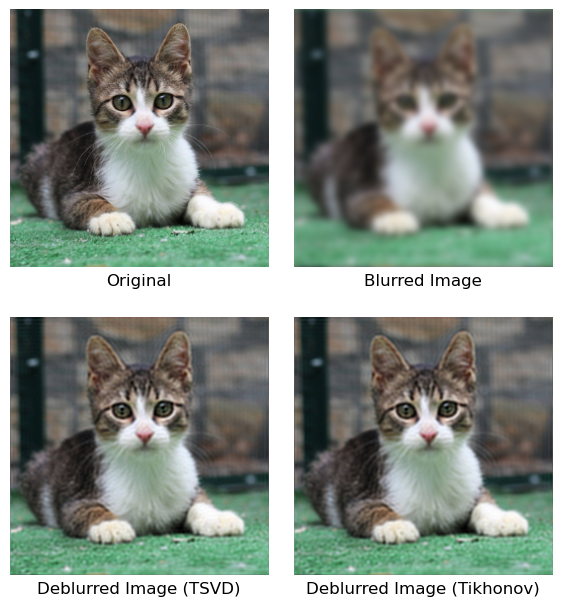

In [7]:
tol = 0.00001
X_tsvd = np.zeros_like(B)
for c in range(3):
    X_tsvd[:, :, c] = compute_tsvd(psf, B[:, :, c], tol)

alpha = 0.00001
X_tik = np.zeros_like(B)
for c in range(3):
    X_tik[:, :, c] = compute_tikhonov(psf, B[:, :, c], alpha)

plot_comparison([img, B, X_tsvd, X_tik ],
          ['Original', 'Blurred Image', 'Deblurred Image (TSVD)', 'Deblurred Image (Tikhonov)'],
          2, 2, figsize=(7, 8))

## Deblurring Images with Noise

### TSVD

/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: divide by zero encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: invalid value encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)


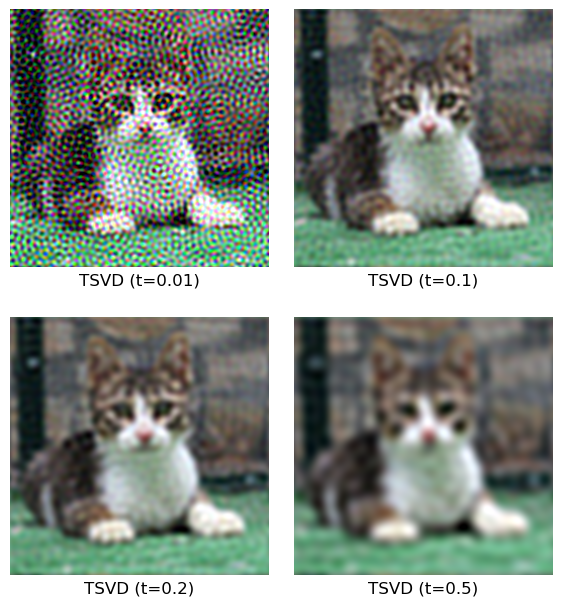

In [8]:
tols = [0.01, 0.1, 0.2, 0.5]

X_tsvd_list = []
for tol in tols:
    X_tsvd = np.zeros_like(B)
    for c in range(3):
        X_tsvd[:, :, c] = compute_tsvd(psf, B_noisy[:, :, c], tol)
    X_tsvd = np.clip(X_tsvd, 0, 1)
    X_tsvd_list.append(X_tsvd)
plot_comparison(X_tsvd_list, ([f'TSVD (t={t})' for t in tols]), 2, 2, figsize=(7,8))

## Tikhonov

/tmp/ipykernel_299/2834776114.py:9: RuntimeWarning: invalid value encountered in divide
  filtered = np.where(eigen_A != 0, tik_filter / eigen_A, 0.0)


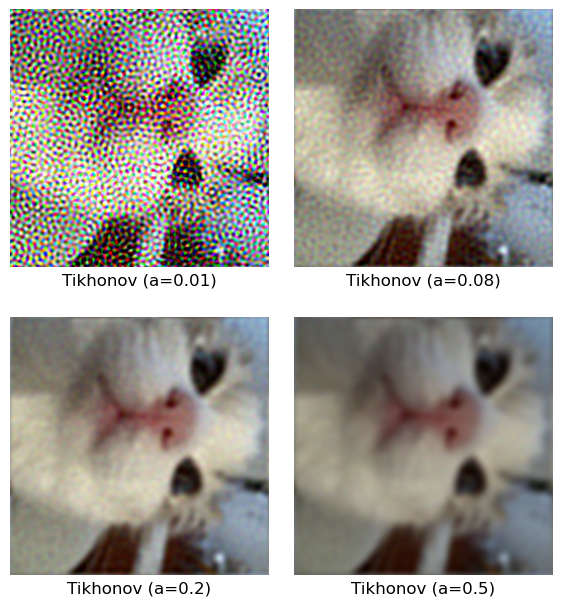

In [24]:
alphas = [0.01, 0.1, 0.2, 0.5]

X_tik_list = []
for alpha in alphas:
    X_tik = np.zeros_like(B)
    for c in range(3):
        X_tik[:, :, c] = compute_tikhonov(psf, B_noisy[:, :, c], alpha)
    X_tik = np.clip(X_tik, 0, 1)
    X_tik_list.append(X_tik)
plot_comparison(X_tik_list, ([f'Tikhonov (a={a})' for a in alphas]), 2, 2, figsize=(7,8))

/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: divide by zero encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: invalid value encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:9: RuntimeWarning: invalid value encountered in divide
  filtered = np.where(eigen_A != 0, tik_filter / eigen_A, 0.0)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13086531323420988..1.019646940761357].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11160970670081327..0.9803826833538968].


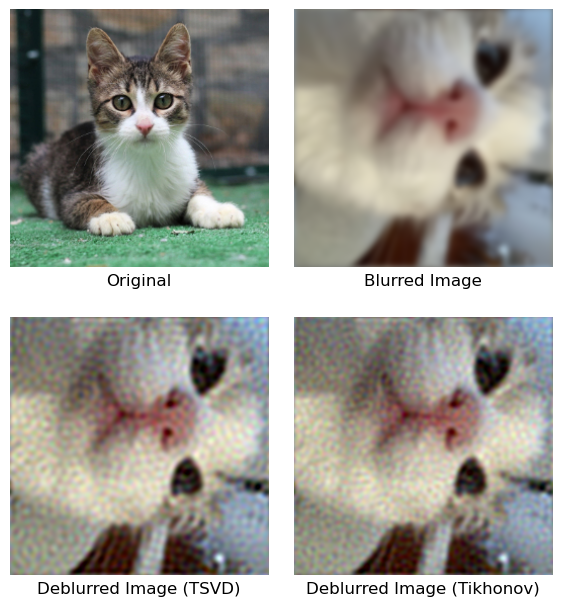

In [40]:
tol = 0.09
X_tsvd = np.zeros_like(B)
for c in range(3):
    X_tsvd[:, :, c] = compute_tsvd(psf, B_noisy[:, :, c], tol)

alpha = 0.09
X_tik = np.zeros_like(B)
for c in range(3): 
    X_tik[:, :, c] = compute_tikhonov(psf, B_noisy[:, :, c], alpha)

plot_comparison([img, B, X_tsvd, X_tik ],
          ['Original', 'Blurred Image', 'Deblurred Image (TSVD)', 'Deblurred Image (Tikhonov)'],
          2, 2, figsize=(7, 8))

## Example 2

In [11]:
img2 = plt.imread('color_deblur_img/kitty.jpg').astype(np.float64)
if img2.max() > 1:
    img2 = img2 / 255.0
H, W = img2.shape[:2]

psf = build_psf(H, W, sigma=3.0)
eigen_A = np.fft.fft2(psf) 

/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: divide by zero encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: invalid value encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:9: RuntimeWarning: invalid value encountered in divide
  filtered = np.where(eigen_A != 0, tik_filter / eigen_A, 0.0)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08185911663935375..1.0195079244018714].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07577255276230632..0.9305521471732514].


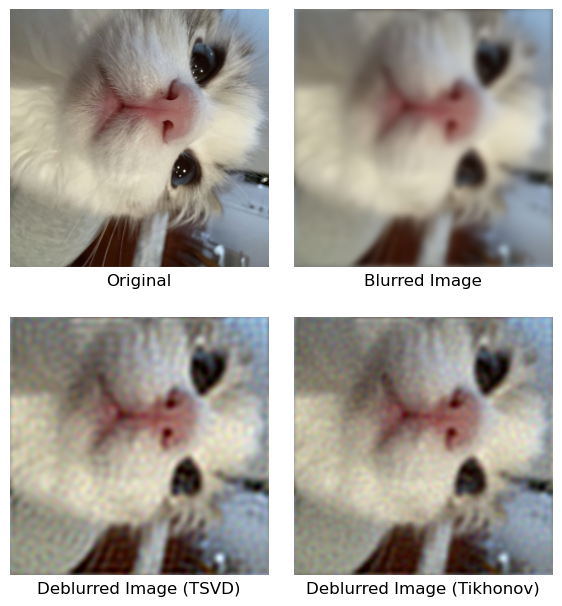

In [12]:
np.random.seed(42)

B = np.zeros_like(img2)
for c in range(3):
    B[:, :, c] = np.real(np.fft.ifft2(eigen_A * np.fft.fft2(img2[:, :, c])))

B_noisy = B + 0.03 * np.random.randn(H, W, 3)

tol = 0.15
X_tsvd = np.zeros_like(B)
for c in range(3):
    X_tsvd[:, :, c] = compute_tsvd(psf, B_noisy[:, :, c], tol)

alpha = 0.15
X_tik = np.zeros_like(B)
for c in range(3): 
    X_tik[:, :, c] = compute_tikhonov(psf, B_noisy[:, :, c], alpha)

plot_comparison([img2, B, X_tsvd, X_tik ],
          ['Original', 'Blurred Image', 'Deblurred Image (TSVD)', 'Deblurred Image (Tikhonov)'],
          2, 2, figsize=(7, 8))

In [26]:
def get_solution_residual_norms_color(deblur_func, psf, blurred_img, at_val):
    eigen_A = np.fft.fft2(psf)
    soln = np.stack([deblur_func(psf, blurred_img[:,:,c], at_val) for c in range(3)], axis=-1)
    residual = blurred_img - np.stack([
        np.real(np.fft.ifft2(eigen_A * np.fft.fft2(soln[:,:,c]))) for c in range(3)], axis=-1)
    return np.linalg.norm(soln), np.linalg.norm(residual)

In [36]:
def plot_l_curve_color(deblur_func, psf, blurred_img, min_val, max_val, title, at_vals):
    _, plot = plt.subplots(figsize=(4,3))
    linvals = np.linspace(min_val, max_val, num=100)
    solution_norms, residual_norms = [], []

    for val in linvals:
        s, r = get_solution_residual_norms_color(deblur_func, psf, blurred_img, val)
        solution_norms.append(s)
        residual_norms.append(r)

    plot.loglog(residual_norms, solution_norms, '-o', markersize=3)

    for val in at_vals:
        s, r = get_solution_residual_norms_color(deblur_func, psf, blurred_img, val)
        plot.plot(r, s, 'o')
        plot.annotate(f'{val}', (r, s), fontsize=8)

    plt.xlabel("Residual Norm ||b - Ax||")
    plt.ylabel("Solution Norm ||x||")
    plt.title(title)
    plt.show()

/tmp/ipykernel_299/2834776114.py:9: RuntimeWarning: invalid value encountered in divide
  filtered = np.where(eigen_A != 0, tik_filter / eigen_A, 0.0)


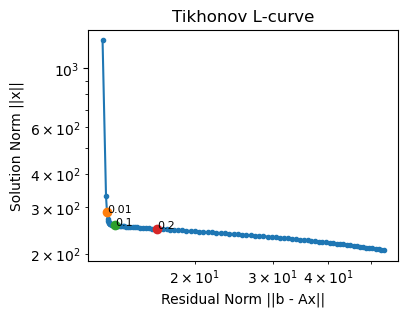

In [37]:
plot_l_curve_color(compute_tikhonov, psf, B_noisy, 0.001, 0.5, 
                   'Tikhonov L-curve', [0.01, 0.1, 0.2])

/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: divide by zero encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)
/tmp/ipykernel_299/2834776114.py:3: RuntimeWarning: invalid value encountered in divide
  tsvd_filter = np.where(np.abs(eigen_A) >= tol, 1.0 / eigen_A, 0.0)


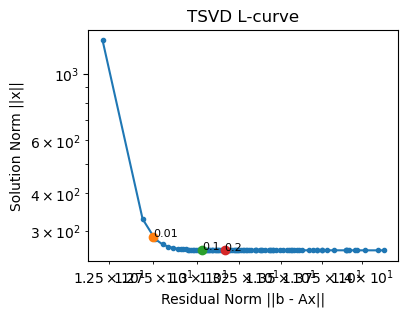

In [38]:
plot_l_curve_color(compute_tsvd, psf, B_noisy, 0.001, 0.5, 
                   'TSVD L-curve', [0.01, 0.1, 0.2])